# 학습내용
2. Ablation Study  
Ablation Study가 무엇인지 알아봅니다.  
3. CIFAR-10 데이터셋 준비  
학습을 위해 CIFAR-10 데이터셋을 준비합니다.  
4. 블록 구성  
VGG 기본 블록을 만들어봅니다.  
5. VGG Complete Model  
VGG 모델을 만들어봅니다  .
6. VGG-16 vs VGG-19  
VGG-16과 VGG-19를 비교실험 합니다.  

실습목표
직접 VGGNet 구현할 수 있습니다.
모델을 config에 따라서 변경 가능하도록 만들수 있습니다.
직접 실험해서 성능을 비교할 수 있습니다.

# 딥러닝 실험이란?
옵션 1. 교재 흐름에 맞춘 정답형 (Ablation Study 언급) - 추천 ⭐
"딥러닝 실험은 모델의 성능을 개선하기 위해 다양한 기법(레이어 추가, 활성화 함수 변경, 규제 적용 등)을 적용하고 그 전후 효과를 정량적으로 비교하는 과정입니다. 특히 논문에서는 핵심 구조나 기능을 하나씩 제거하거나 변경해보며 해당 요소가 성능에 미치는 영향을 검증하는 '아블레이션 스터디(Ablation Study)' 형태로 실험을 설계하여 모델의 타당성을 증명합니다."

옵션 2. 핵심만 간단히 요약한 버전 (글자 수 제한 대비)
"딥러닝 모델의 성능을 높이기 위해 데이터셋 준비, 모델 블록 구성, 하이퍼파라미터 변경 등 다양한 변수를 통제하며 결과를 비교하는 과정입니다. 특정 기법을 적용했을 때와 아닐 때의 차이를 에러율이나 정확도 같은 지표로 시각화하여, 제안한 방법론의 효과를 객관적으로 체체감하고 증명하는 필수적인 연구 단계입니다."

옵션 3. 개발자 관점의 직관적인 버전
"딥러닝에서 이론으로 배운 VGG, ResNet 등의 백본 네트워크를 직접 구현하고, 가설에 따라 구조를 변경(Config 조절)해 가며 실제 데이터셋(CIFAR-10 등)에서 성능 차이를 눈으로 확인하는 반복적인 검증 프로세스입니다."

# Ablation Study
저희가 지금부터 해볼 프로젝트는 애블레이션 연구(ablation study) 입니다. 직역하자면 '제거 연구'정도가 되겠네요.

딥러닝 논문은 여러 가지 방법들을 결합해서 어떤 문제를 해결하는 방법을 제시합니다. 이때 제안한 방법들의 유효함을 증명하기 위해서 보통 딥러닝 논문에서는 해당 방법을 "제거"한 모델로 수행한 실험과, 해당 방법을 추가한 모델로 수행한 실험의 결과를 비교합니다. 애블레이션 연구란 이처럼 "아이디어를 제거해 봄으로써" 제안한 방법이 어떻게 성능이나 문제에 해결에 효과를 주는지 확인하는 실험입니다.

아래는 ResNet 논문에서 제시한 residual connection의 애블레이션 연구입니다. 이미지넷(ImageNet) 검증 데이터셋(validation dataset)에 대한 Top-1 error rate을 지표로 사용해 residual connection이 없는 일반 네트워크(plain net)와 ResNet을 비교하였습니다. 이 비교를 통해서 ResNet이 residual connection을 활용해서 깊은 네트워크를 쌓았을 때, 이를 통한 성능 향상을 얻을 수 있음을 증명하고 있습니다.
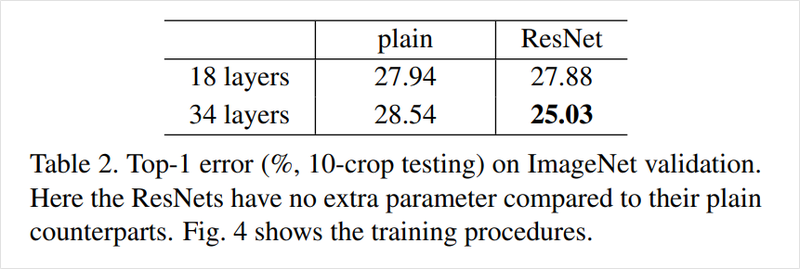

Q. Ablation Study가 필요한 이유를 찾아보고 정리해 봅시다.
Ablation Study(제거 연구)가 필수적인 이유는 한 마디로 "독립변수와 종속변수 사이의 인과관계를 증명하기 위해서"입니다.

요소별 기여도 파악: 딥러닝 모델에 A, B, C라는 3가지 기법을 동시에 적용해 성능이 올랐을 때, 진짜 성능을 올린 핵심이 A인지, B인지, 혹은 C인지 알 수 없습니다. 이때 하나씩 빼보며 진짜 '주인공' 기법을 찾아냅니다.

모델의 타당성 및 신뢰성 검증: "우리가 제안한 이 레이어(예: ResNet의 Shortcut Connection) 덕분에 이만큼의 에러율이 줄어들었다"라는 것을 정량적 데이터(지표)로 시각화하여 논문의 논리적 설득력을 부여합니다.

효율적인 모델 경량화: 성능에 거의 영향을 주지 않는 불필요한 기법이나 레이어를 발견하고 제거하여 연산 효율성을 높일 수 있습니다.

# CIFAR-10
그럼 우리가 이번에 모델을 사용해서 풀어야 할 문제가 무엇인지 확인해보도록 합시다. CIFAR-10 데이터셋은 10개 카테고리에 대해 총 6만 장의 이미지가 있습니다. 각 이미지들의 가로, 세로는 각각 32 픽셀(pixel)입니다. MNIST에서 손글씨가 나타내는 숫자를 분류해내었던 것처럼 CIFAR-10 데이터셋을 사용해 물체의 종류를 분류해보도록 하겠습니다.

먼저 데이터셋을 준비하겠습니다.


In [1]:
# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
!pip install torchinfo
from torchinfo import summary
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


CIFAR-10은 대용량 데이터셋은 아니지만 그래도 로드되는 데 꽤 긴 시간이 걸립니다. 잠깐 커피를 드시면서 숨을 돌리셔도 좋습니다.

데이터셋이 준비되면 클래스의 수와 클래스에 따른 이름을 볼 수 있습니다. DatasetBuilder의 info를 통해 정보를 확인해 보세요.

❗️ 데이터셋은 설정해둔 root 경로에 다운로드합니다. 데이터셋 크기가 커서 하나의 폴더에 모아놓고 사용하는 것도 좋은 방법이므로, ~/work 프로젝트 폴더가 아닌 기본 경로에 다운 받아 사용하시면 됩니다. 혹시 데이터셋 경로를 바꾸고 싶으시다면, root 인자를 사용하세요.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

In [3]:
# 데이터셋을 로드하고 기본 정보를 확인해 보세요.
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

Image shape: torch.Size([3, 32, 32])
Label: 6
Number of classes: 10


In [4]:
# 데이터의 개수도 확인해 봅시다.
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Train dataset size: 50000 (Shape: torch.Size([]))
Test dataset size: 10000 (Shape: torch.Size([]))


Pytorch의 데이터셋은 Numpy가 아니므로 ds_train.shape 같은 게 존재하지 않습니다. 위와 같은 방법으로 데이터셋의 이미지 shape와 전체 데이터의 개수, 라벨 클래스의 개수 등 가장 중요한 정보들이 잘 확인되었나요?

# Pytorch의 데이터셋은 Numpy가 아니므로 ds_train.shape 같은 게 존재하지 않습니다. 위와 같은 방법으로 데이터셋의 이미지 shape와 전체 데이터의 개수, 라벨 클래스의 개수 등 가장 중요한 정보들이 잘 확인되었나요?

Data Normalization 은 데이터의 범위를 사용자가 원하는 범위로 제한하는 것입니다. 이미지 데이터의 경우 픽셀 정보를 0~ 255 사이의 값으로 가지는데, 이를 255로 나누어주면 0~1.0 사이의 값을 가지게 될 거예요. 위의 예를 수식으로 간단하게 쓴다면, (정규화하고자 하는 값 - 데이터 값들 중 최소값) / (데이터 값들 중 최대값 - 데이터 값들 중 최소값) 이죠.

x
−
x
min
⁡
x
max
⁡
−
x
min
⁡/
x 
max
​
 −x 
min
​
 
x−x 
min
​
 
​
 

Data Normalization을 하는 이유는 머신러닝에서 scale이 큰 feature의 영향이 비대해지는 것을 방지하고, 딥러닝에서 Local optimum에 빠질 위험을 줄이는(학습 속도 향상) 거예요.

아래 그림을 보면 왼쪽이 정규화 하지 않은 경우의 Cost function 이고 오른쪽이 정규화 한 Cost function 일 때, 정규화 한 경우가 Local optimum 에서 더 빨리 빠져나올 수 있다는 것을 직관적으로 이해할 수 있습니다.그리고 scikit-learn에서 MinMaxScaler로 쉽게 사용 할 수 있어요.

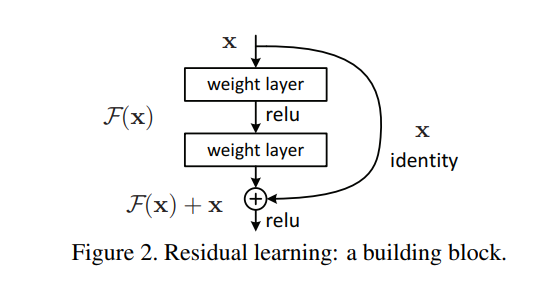

우리는 "가로 1920, 세로 1080 픽셀의 이미지"처럼 픽셀의 수를 사용해 이미지의 크기를 말할 수 있는데요. 이때 한 픽셀이 가진 채널(channel) 값은 픽셀의 색을 표현합니다. RGB는 Red, Green, Blue로 세 가지 색을 조합해서 우리가 보는 다양한 색을 만들어내는 방법이죠. 그레이 스케일(gray scale)은 단순하게 흑과 백만을 표현하는 하나의 채널을 가진 이미지입니다. RGB나 그레이 스케일 외에도 HSV, CMYK 등 인쇄 또는 이미지 작업을 위해 사용되는 다양한 채널 체계가 있습니다.

우리의 모델에 넣어주기 전에는 각 채널별 최댓값인 255로 정규화(normalize) 를 해주어 이미지의 표현이 0과 1 사이로 들어오도록 만들어줍니다. 직접 정규화 코드를 작성해봅시다.

In [5]:
# Q. 이미지의 표현이 0과 1 사이로 들어오도록 직접 Pytorch 정규화 코드를 작성해봅시다.
transform = transforms.Compose([
    transforms.ToTensor()  # uint8 → float32 변환 + 0~1 정규화
])

In [6]:
num_classes = len(trainset.classes)
print(num_classes)

10


In [7]:
class_names = trainset.classes
print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [8]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))


In [9]:
def show_multiple_images(dataset, n_images=9):
    dataiter = iter(dataset)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    axes = axes.flatten()

    for i in range(n_images):
        ax = axes[i]
        img = imshow(images[i])
        ax.imshow(img)
        ax.set_title(f"Label: {trainset.classes[labels[i]]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

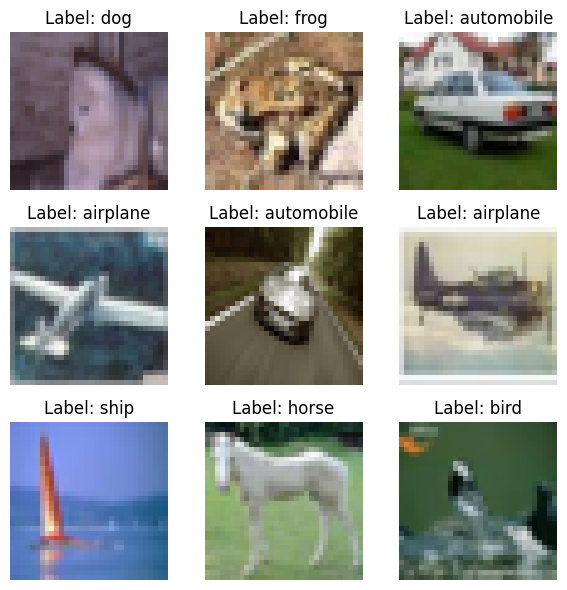

In [11]:
# 학습 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(trainloader)

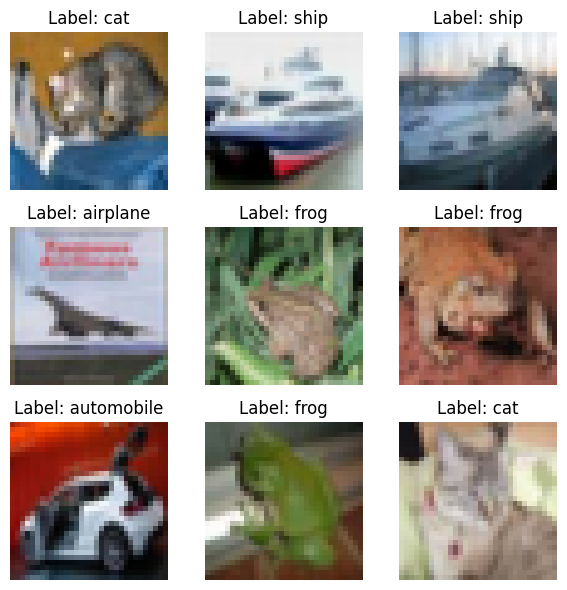

In [12]:
# 테스트 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(testloader)